# Flu Modeling Exploration — Illinois

This notebook performs the first modeling pass for the flu outbreak prediction project.

## Goals
- Load the processed weekly flu-weather dataset
- Define an outbreak label from the continuous flu signal
- Create lag-based predictive features
- Train baseline models for multiple prediction horizons
- Generate the first prediction-horizon vs performance results

## Modeling scope for this notebook
This is the first exploratory modeling notebook, so the focus is on:
- simple outbreak labeling
- lag-based features
- baseline models
- time-aware train/test evaluation

## Planned horizons
We will predict whether an outbreak occurs at:

- 1 week ahead
- 2 weeks ahead
- 3 weeks ahead
- 4 weeks ahead

## Notes
- This notebook uses the processed output from `00_flu_data_build.ipynb`
- We begin with simple and interpretable baselines
- More advanced feature engineering and cross-disease comparisons come later

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

sys.path.append(str(Path("..").resolve()))

from config import FILES, savefig, print_config_summary

print_config_summary()

===== CONFIG SUMMARY =====
Base Dir: /Users/suvo/Projects/disease-outbreak
Default Disease: flu
Default Region: illinois
Forecast Horizons: [1, 2, 3, 4]
Default Lags: [1, 2, 3, 4]
Default Outbreak Quantile: 0.85
Raw Data Dir: /Users/suvo/Projects/disease-outbreak/data/raw
Interim Data Dir: /Users/suvo/Projects/disease-outbreak/data/interim
Processed Data Dir: /Users/suvo/Projects/disease-outbreak/data/processed
Figures Dir: /Users/suvo/Projects/disease-outbreak/outputs/figures
Tables Dir: /Users/suvo/Projects/disease-outbreak/outputs/tables
Models Dir: /Users/suvo/Projects/disease-outbreak/outputs/models
Flu Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/fluview_il_201040_202652.json
Flu Weather Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/weather_openmeteo_springfield_il_2010-10-01_2026-04-10.json


In [4]:
df = pd.read_parquet(FILES["flu_weekly_merged_parquet"]).copy()

print(df.shape)
display(df.head())

(808, 23)


,release_date,region,issue,epiweek,lag,num_ili,num_patients,num_providers,num_age_0,num_age_1,...,num_age_5,wili,ili,week_start,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,outbreak
0,2017-10-24,il,201740,201040,365,505,39390,74,None,None,...,None,1.28205,1.28205,2010-10-03,25.566667,10.933333,0.0,20.766667,18.210000,0
1,2017-10-24,il,201740,201041,364,600,41354,76,None,None,...,None,1.45089,1.45089,2010-10-10,24.557143,9.700000,0.2,31.342857,17.417143,0
2,2017-10-24,il,201740,201042,363,644,41122,76,None,None,...,None,1.56607,1.56607,2010-10-17,22.314286,7.571429,0.0,16.700000,16.500000,0
3,2017-10-24,il,201740,201043,362,623,42741,79,None,None,...,None,1.45762,1.45762,2010-10-24,19.057143,6.557143,7.4,25.342857,12.132857,0
4,2017-10-24,il,201740,201044,361,625,41966,79,None,None,...,None,1.48930,1.48930,2010-10-31,11.928571,0.585714,0.0,14.271429,13.637143,0


In [5]:
df["week_start"] = pd.to_datetime(df["week_start"])
df = df.sort_values("week_start").reset_index(drop=True)

print(df.dtypes)

release_date                          str
region                                str
issue                               int64
epiweek                             int64
lag                                 int64
num_ili                             int64
num_patients                        int64
num_providers                       int64
num_age_0                          object
num_age_1                          object
num_age_2                          object
num_age_3                          object
num_age_4                          object
num_age_5                          object
wili                              float64
ili                               float64
week_start                 datetime64[ms]
temperature_2m_max                float64
temperature_2m_min                float64
precipitation_sum                 float64
wind_speed_10m_max                float64
shortwave_radiation_sum           float64
outbreak                            int64
dtype: object


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/flu/flu_wili_model_input.png


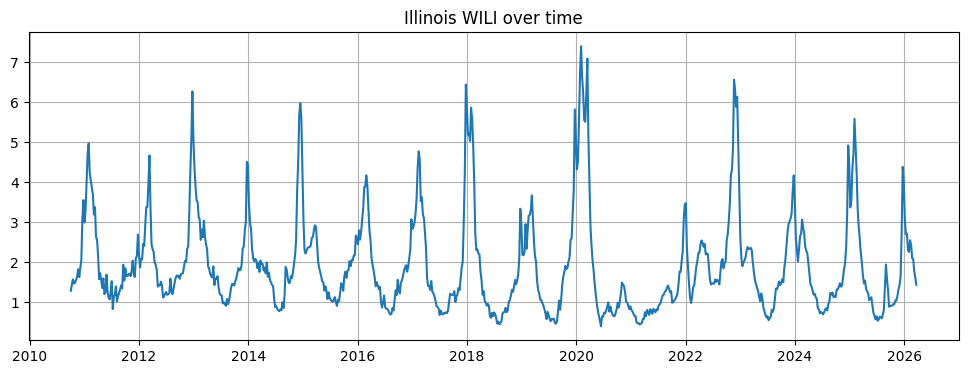

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["week_start"], df["wili"])
ax.set_title("Illinois WILI over time")
ax.grid(True)

savefig(fig, "flu_wili_model_input.png", subdir="flu")
plt.show()

In [7]:
for q in [0.80, 0.85, 0.90]:
    print(f"Quantile {q:.2f}: {df['wili'].quantile(q):.4f}")

Quantile 0.80: 2.6319
Quantile 0.85: 3.0369
Quantile 0.90: 3.5460


In [8]:
outbreak_quantile = 0.85
threshold = df["wili"].quantile(outbreak_quantile)

df["outbreak"] = (df["wili"] >= threshold).astype(int)

print("Threshold:", threshold)
print("Outbreak rate:", df["outbreak"].mean())

Threshold: 3.0369365
Outbreak rate: 0.15099009900990099


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/flu/flu_outbreak_labeling_85th_percentile.png


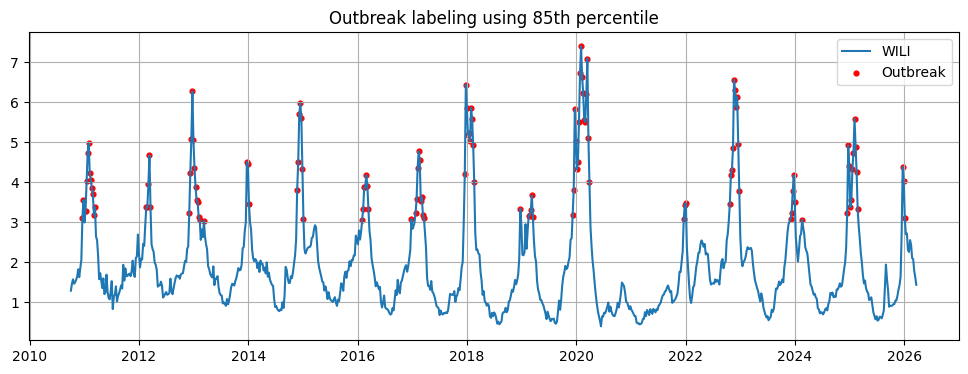

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["week_start"], df["wili"], label="WILI")

mask = df["outbreak"] == 1
ax.scatter(
    df.loc[mask, "week_start"],
    df.loc[mask, "wili"],
    color="red",
    s=12,
    label="Outbreak"
)

ax.set_title("Outbreak labeling using 85th percentile")
ax.legend()
ax.grid(True)

savefig(fig, "flu_outbreak_labeling_85th_percentile.png", subdir="flu")
plt.show()

In [12]:
cols_to_drop = [
    "num_age_0", "num_age_1", "num_age_2",
    "num_age_3", "num_age_4", "num_age_5"
]

df = df.drop(columns=cols_to_drop)

In [13]:
for lag in [1, 2, 3, 4]:
    df[f"wili_lag_{lag}"] = df["wili"].shift(lag)

lag_cols = [f"wili_lag_{lag}" for lag in [1, 2, 3, 4]]

df_lagged = df.dropna(subset=lag_cols).reset_index(drop=True)

print(df_lagged.shape)
display(df_lagged.head())

(804, 21)


,release_date,region,issue,epiweek,lag,num_ili,num_patients,num_providers,wili,ili,...,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,outbreak,wili_lag_1,wili_lag_2,wili_lag_3,wili_lag_4
0,2017-10-24,il,201740,201044,361,625,41966,79,1.48930,1.48930,...,11.928571,0.585714,0.0,14.271429,13.637143,0,1.45762,1.56607,1.45089,1.28205
1,2017-10-24,il,201740,201045,360,651,41894,80,1.55392,1.55392,...,13.271429,0.585714,0.0,17.542857,12.941429,0,1.48930,1.45762,1.56607,1.45089
2,2017-10-24,il,201740,201046,359,661,40492,79,1.63242,1.63242,...,13.114286,-2.114286,0.0,16.871429,12.328571,0,1.55392,1.48930,1.45762,1.56607
3,2017-10-24,il,201740,201047,358,622,34238,78,1.81669,1.81669,...,10.000000,-3.085714,0.0,22.785714,10.915714,0,1.63242,1.55392,1.48930,1.45762
4,2017-10-24,il,201740,201048,357,659,40646,79,1.62132,1.62132,...,6.271429,-6.685714,0.0,16.514286,10.275714,0,1.81669,1.63242,1.55392,1.48930


## Feature: WILI

In [60]:
feature_cols = [
    "wili_lag_1",
    "wili_lag_2",
    "wili_lag_3",
    "wili_lag_4",
]

print(feature_cols)

['wili_lag_1', 'wili_lag_2', 'wili_lag_3', 'wili_lag_4']


In [61]:
split_date = pd.Timestamp("2020-01-01")

train_df = df_lagged[df_lagged["week_start"] < split_date].copy()
test_df = df_lagged[df_lagged["week_start"] >= split_date].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train outbreak rate:", train_df["outbreak"].mean())
print("Test outbreak rate:", test_df["outbreak"].mean())

Train shape: (479, 27)
Test shape: (325, 27)
Train outbreak rate: 0.15866388308977036
Test outbreak rate: 0.14153846153846153


In [62]:
X_train = train_df[feature_cols]
y_train = train_df["outbreak"]

X_test = test_df[feature_cols]
y_test = test_df["outbreak"]

In [63]:
threshold = train_df["wili"].quantile(0.85)

In [64]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf, digits=4))

Random Forest
              precision    recall  f1-score   support

           0     0.9750    0.9785    0.9767       279
           1     0.8667    0.8478    0.8571        46

    accuracy                         0.9600       325
   macro avg     0.9208    0.9132    0.9169       325
weighted avg     0.9597    0.9600    0.9598       325



In [65]:
results = []

for horizon in [1, 2, 3, 4]:
    temp = df.copy()

    temp[f"outbreak_h{horizon}"] = temp["outbreak"].shift(-horizon)

    for lag in [1, 2, 3, 4]:
        temp[f"wili_lag_{lag}"] = temp["wili"].shift(lag)

    temp = temp.dropna().reset_index(drop=True)

    train_temp = temp[temp["week_start"] < split_date].copy()
    test_temp = temp[temp["week_start"] >= split_date].copy()

    X_train = train_temp[feature_cols]
    y_train = train_temp[f"outbreak_h{horizon}"].astype(int)

    X_test = test_temp[feature_cols]
    y_test = test_temp[f"outbreak_h{horizon}"].astype(int)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "horizon_weeks": horizon,
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "n_train": len(train_temp),
        "n_test": len(test_temp),
    })

results_df = pd.DataFrame(results)
results_df

,horizon_weeks,f1,precision,recall,n_train,n_test
0,1,0.777778,0.777778,0.777778,479,324
1,2,0.617284,0.675676,0.568182,479,323
2,3,0.500000,0.512195,0.488372,479,322
3,4,0.388889,0.466667,0.333333,479,321


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/flu/flu_prediction_horizon_curve_baseline.png


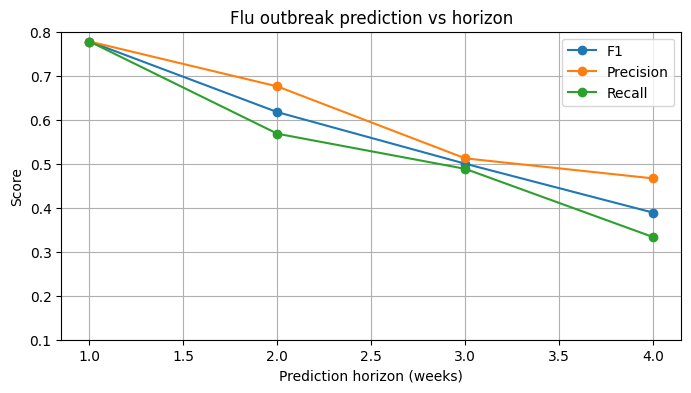

In [66]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df["horizon_weeks"], results_df["f1"], marker="o", label="F1")
ax.plot(results_df["horizon_weeks"], results_df["precision"], marker="o", label="Precision")
ax.plot(results_df["horizon_weeks"], results_df["recall"], marker="o", label="Recall")

ax.set_xlabel("Prediction horizon (weeks)")
ax.set_ylabel("Score")
ax.set_title("Flu outbreak prediction vs horizon")
ax.legend()
ax.grid(True)
ax.set_ylim(0.1, 0.8)

savefig(fig, "flu_prediction_horizon_curve_baseline.png", subdir="flu")
plt.show()

In [27]:
results_df

,horizon_weeks,f1,precision,recall,n_train,n_test
0,1,0.777778,0.777778,0.777778,479,324
1,2,0.617284,0.675676,0.568182,479,323
2,3,0.500000,0.512195,0.488372,479,322
3,4,0.388889,0.466667,0.333333,479,321


## Feature: WILI + Weather

In [67]:
for lag in [1, 2, 3]:
    df[f"temp_max_lag_{lag}"] = df["temperature_2m_max"].shift(lag)
    df[f"precip_lag_{lag}"] = df["precipitation_sum"].shift(lag)

In [68]:
feature_cols = [
    "wili_lag_1",
    "wili_lag_2",
    "wili_lag_3",
    "wili_lag_4",
    
    "temp_max_lag_1",
    "temp_max_lag_2",
    "precip_lag_1",
    "precip_lag_2",
]

print(feature_cols)

['wili_lag_1', 'wili_lag_2', 'wili_lag_3', 'wili_lag_4', 'temp_max_lag_1', 'temp_max_lag_2', 'precip_lag_1', 'precip_lag_2']


In [69]:
lag_cols = feature_cols
df_lagged = df.dropna(subset=lag_cols).reset_index(drop=True)

In [70]:
split_date = pd.Timestamp("2020-01-01")

train_df = df_lagged[df_lagged["week_start"] < split_date].copy()
test_df = df_lagged[df_lagged["week_start"] >= split_date].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train outbreak rate:", train_df["outbreak"].mean())
print("Test outbreak rate:", test_df["outbreak"].mean())

Train shape: (479, 27)
Test shape: (325, 27)
Train outbreak rate: 0.15866388308977036
Test outbreak rate: 0.14153846153846153


In [71]:
X_train = train_df[feature_cols]
y_train = train_df["outbreak"]

X_test = test_df[feature_cols]
y_test = test_df["outbreak"]

In [72]:
threshold = train_df["wili"].quantile(0.85)

In [73]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf, digits=4))

Random Forest
              precision    recall  f1-score   support

           0     0.9579    0.9785    0.9681       279
           1     0.8500    0.7391    0.7907        46

    accuracy                         0.9446       325
   macro avg     0.9039    0.8588    0.8794       325
weighted avg     0.9426    0.9446    0.9430       325



In [74]:
results = []

for horizon in [1, 2, 3, 4]:
    temp = df.copy()

    temp[f"outbreak_h{horizon}"] = temp["outbreak"].shift(-horizon)

    for lag in [1, 2, 3, 4]:
        temp[f"wili_lag_{lag}"] = temp["wili"].shift(lag)

    temp = temp.dropna().reset_index(drop=True)

    train_temp = temp[temp["week_start"] < split_date].copy()
    test_temp = temp[temp["week_start"] >= split_date].copy()

    X_train = train_temp[feature_cols]
    y_train = train_temp[f"outbreak_h{horizon}"].astype(int)

    X_test = test_temp[feature_cols]
    y_test = test_temp[f"outbreak_h{horizon}"].astype(int)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "horizon_weeks": horizon,
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "n_train": len(train_temp),
        "n_test": len(test_temp),
    })

results_df = pd.DataFrame(results)
results_df

,horizon_weeks,f1,precision,recall,n_train,n_test
0,1,0.582278,0.676471,0.511111,479,324
1,2,0.493827,0.540541,0.454545,479,323
2,3,0.314286,0.407407,0.255814,479,322
3,4,0.281250,0.409091,0.214286,479,321


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/flu/flu_prediction_horizon_curve_baseline.png


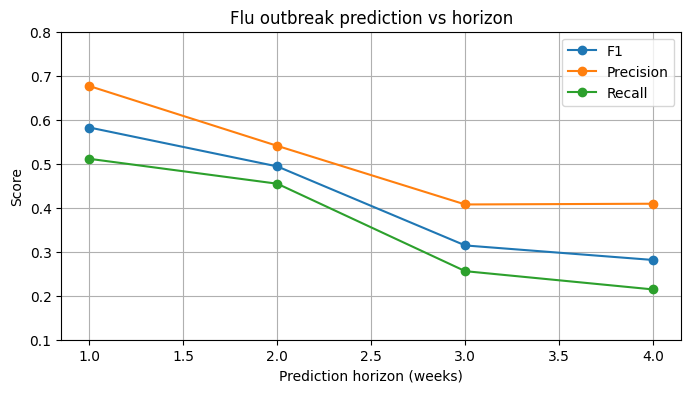

In [75]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df["horizon_weeks"], results_df["f1"], marker="o", label="F1")
ax.plot(results_df["horizon_weeks"], results_df["precision"], marker="o", label="Precision")
ax.plot(results_df["horizon_weeks"], results_df["recall"], marker="o", label="Recall")

ax.set_xlabel("Prediction horizon (weeks)")
ax.set_ylabel("Score")
ax.set_title("Flu outbreak prediction vs horizon")
ax.legend()
ax.grid(True)
ax.set_ylim(0.1, 0.8)

savefig(fig, "flu_prediction_horizon_curve_baseline.png", subdir="flu")
plt.show()